<a href="https://colab.research.google.com/github/guilhermemoraes-lasalle/ColecoesEassociacoes/blob/main/Atividade_Explorando_Dados_Web_Python_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática — Explorando Dados na Web com Python

Este notebook aborda requisições HTTP, APIs, tratamento de erros, download de arquivos, web scraping e leitura de tabelas HTML.

## Conteúdos
- `requests`
- parâmetros GET
- cabeçalhos HTTP
- JSON
- tratamento de exceções
- download de arquivos binários
- `robots.txt`
- BeautifulSoup
- Pandas
- `read_html()`
- exportação para CSV

> **Observação:** este notebook foi preparado para execução no Google Colab e requer acesso à internet.


## Instalação e importação das bibliotecas


In [1]:
!pip -q install requests beautifulsoup4 lxml pandas


In [2]:
import requests
import pandas as pd

from bs4 import BeautifulSoup
from io import StringIO

# Cabeçalho utilizado nas requisições
HEADERS = {
    "User-Agent": "ProjetoExplorandoDadosWeb/1.0"
}

print("Bibliotecas carregadas com sucesso!")


Bibliotecas carregadas com sucesso!


# Nível 1 — Básico: URLs, Parâmetros e Cabeçalhos


## Exercícios 1.1, 1.2, 1.3 e 1.4 — JSONPlaceholder


In [3]:
url = "https://jsonplaceholder.typicode.com/posts"

# Filtrando apenas os posts do usuário 2
parametros = {
    "userId": 2
}

resposta = requests.get(
    url,
    params=parametros,
    headers=HEADERS,
    timeout=10
)

print("Código HTTP:", resposta.status_code)
print("URL final:", resposta.url)

# Interrompe com erro caso a resposta HTTP não seja bem-sucedida
resposta.raise_for_status()

dados_posts = resposta.json()

print("\nQuantidade de registros retornados:", len(dados_posts))

df_posts = pd.DataFrame(dados_posts)

display(df_posts.head())


Código HTTP: 200
URL final: https://jsonplaceholder.typicode.com/posts?userId=2

Quantidade de registros retornados: 10


,userId,id,title,body
0,2,11,et ea vero quia laudantium autem,delectus reiciendis molestiae occaecati non mi...
1,2,12,in quibusdam tempore odit est dolorem,itaque id aut magnam\npraesentium quia et ea o...
2,2,13,dolorum ut in voluptas mollitia et saepe quo a...,aut dicta possimus sint mollitia voluptas comm...
3,2,14,voluptatem eligendi optio,fuga et accusamus dolorum perferendis illo vol...
4,2,15,eveniet quod temporibus,reprehenderit quos placeat\nvelit minima offic...


### Resultado esperado

A requisição utiliza:

- método HTTP `GET`;
- parâmetro `userId=2`;
- cabeçalho `User-Agent` personalizado;
- `timeout=10`;
- leitura da resposta em JSON;
- conversão dos resultados para um DataFrame.


# Nível 2 — Intermediário: JSON, Erros e Arquivos Binários


## Exercício 2.1 — Consulta de CEPs com ViaCEP


In [4]:
ceps = [
    "01001000",
    "20040002",
    "30140071"
]

resultados_ceps = []

for cep in ceps:
    url_cep = f"https://viacep.com.br/ws/{cep}/json/"

    try:
        resposta = requests.get(
            url_cep,
            headers=HEADERS,
            timeout=10
        )

        resposta.raise_for_status()

        dados_cep = resposta.json()

        if dados_cep.get("erro"):
            print(f"CEP {cep} não encontrado.")
        else:
            resultados_ceps.append(dados_cep)

    except requests.RequestException as erro:
        print(
            f"Erro ao consultar o CEP {cep}: {erro}"
        )

df_ceps = pd.DataFrame(resultados_ceps)

print("CEPs consultados:")
display(
    df_ceps[
        [
            "cep",
            "logradouro",
            "bairro",
            "localidade",
            "uf"
        ]
    ]
)


CEPs consultados:


,cep,logradouro,bairro,localidade,uf
0,01001-000,Praça da Sé,Sé,São Paulo,SP
1,20040-002,Avenida Rio Branco,Centro,Rio de Janeiro,RJ
2,30140-071,Rua dos Aimorés,Boa Viagem,Belo Horizonte,MG


## Exercício 2.2 — Função de download segura com `try/except`


In [5]:
def download_seguro(url, nome_arquivo):
    try:
        resposta = requests.get(
            url,
            headers=HEADERS,
            timeout=10
        )

        # Gera uma exceção para respostas 4xx e 5xx
        resposta.raise_for_status()

        with open(nome_arquivo, "wb") as arquivo:
            arquivo.write(resposta.content)

        print(
            f"Download concluído com sucesso: {nome_arquivo}"
        )

        return True

    except requests.exceptions.Timeout:
        print(
            "A requisição demorou demais e foi interrompida."
        )

    except requests.exceptions.HTTPError as erro:
        print(
            f"Erro HTTP durante o download: {erro}"
        )

    except requests.exceptions.RequestException as erro:
        print(
            f"Falha na requisição: {erro}"
        )

    return False


print("Função criada com sucesso!")


Função criada com sucesso!


## Exercício 2.3 — Download de uma imagem aleatória


In [6]:
url_imagem = "https://picsum.photos/400/400"

download_seguro(
    url_imagem,
    "imagem_aleatoria.jpg"
)


Download concluído com sucesso: imagem_aleatoria.jpg


True

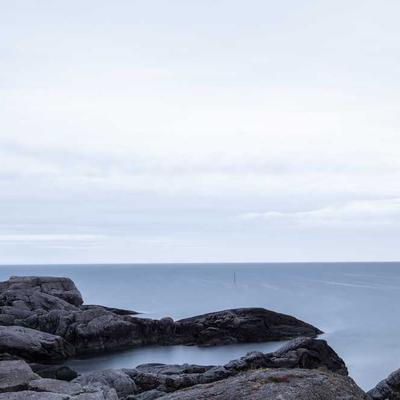

In [7]:
# Visualizando a imagem baixada no Google Colab
from IPython.display import Image, display

display(
    Image(
        filename="imagem_aleatoria.jpg",
        width=400
    )
)


# Nível 3 — Avançado: Web Scraping e Ética


## Exercício 3.1 — Verificação do `robots.txt`

Antes de realizar a raspagem, consultamos o arquivo `robots.txt` do site **Books to Scrape** para verificar as orientações disponibilizadas pelo servidor.


In [8]:
url_robots = "https://books.toscrape.com/robots.txt"

try:
    resposta_robots = requests.get(
        url_robots,
        headers=HEADERS,
        timeout=10
    )

    print(
        "Código HTTP do robots.txt:",
        resposta_robots.status_code
    )

    if resposta_robots.ok:
        print("\nConteúdo do robots.txt:")
        print(resposta_robots.text)
    else:
        print(
            "O servidor não disponibilizou o robots.txt "
            "com uma resposta HTTP de sucesso."
        )

except requests.RequestException as erro:
    print(
        "Não foi possível consultar o robots.txt:",
        erro
    )


Código HTTP do robots.txt: 404
O servidor não disponibilizou o robots.txt com uma resposta HTTP de sucesso.


> A ausência ou indisponibilidade de um `robots.txt` não deve ser interpretada automaticamente como autorização irrestrita. Neste exercício usamos um site criado especificamente para prática de web scraping e fazemos poucas requisições.


## Exercício 3.2 — Extração dos 5 primeiros livros


In [9]:
url_livros = "https://books.toscrape.com/"

resposta_livros = requests.get(
    url_livros,
    headers=HEADERS,
    timeout=10
)

resposta_livros.raise_for_status()

soup = BeautifulSoup(
    resposta_livros.text,
    "html.parser"
)

livros_html = soup.select(
    "article.product_pod"
)[:5]

livros = []

for livro in livros_html:
    titulo = livro.select_one(
        "h3 a"
    ).get("title")

    preco = livro.select_one(
        ".price_color"
    ).get_text(strip=True)

    livros.append({
        "titulo": titulo,
        "preco": preco
    })

df_livros = pd.DataFrame(livros)

print("5 primeiros livros encontrados:")
display(df_livros)


5 primeiros livros encontrados:


,titulo,preco
0,A Light in the Attic,Â£51.77
1,Tipping the Velvet,Â£53.74
2,Soumission,Â£50.10
3,Sharp Objects,Â£47.82
4,Sapiens: A Brief History of Humankind,Â£54.23


## Exercício 3.3 — Exportação dos livros para CSV


In [10]:
df_livros.to_csv(
    "livros_extraidos.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Arquivo livros_extraidos.csv criado com sucesso!"
)


Arquivo livros_extraidos.csv criado com sucesso!


## Exercício 3.4 — Leitura de tabela da Wikipedia com `read_html()`


In [11]:
url_wikipedia = (
    "https://en.wikipedia.org/wiki/"
    "List_of_countries_and_dependencies_by_population"
)

try:
    resposta_wikipedia = requests.get(
        url_wikipedia,
        headers=HEADERS,
        timeout=15
    )

    resposta_wikipedia.raise_for_status()

    # StringIO transforma o HTML em um objeto de texto
    html = StringIO(
        resposta_wikipedia.text
    )

    tabelas = pd.read_html(html)

    print(
        "Quantidade de tabelas encontradas:",
        len(tabelas)
    )

    # A primeira tabela principal da página
    df_populacao = tabelas[0]

    print("\nPrimeiras linhas da tabela:")
    display(df_populacao.head(10))

except requests.RequestException as erro:
    print(
        "Erro ao acessar a Wikipedia:",
        erro
    )


Quantidade de tabelas encontradas: 3

Primeiras linhas da tabela:


,Location,Population,% of world,Date,Source (official or from the United Nations),Notes
0,World,8.232000e+09,100%,13 Jun 2025,UN projection[1][3],NaN
1,India,1.429404e+09,17.3%,1 Jul 2026,Official projection[4],[b]
2,China,1.404890e+09,17.0%,31 Dec 2025,Official estimate[5],[c]
3,United States,3.417849e+08,4.1%,1 Jul 2025,Official estimate[6],[d]
4,Indonesia,2.883151e+08,3.5%,31 Dec 2025,National annual projection[7],NaN
5,Pakistan,2.414994e+08,2.9%,1 Mar 2023,2023 census result[8],[e]
6,Nigeria,2.238000e+08,2.7%,1 Jul 2023,Official projection[9],NaN
7,Brazil,2.142120e+08,2.6%,1 Jul 2026,Official estimate[10],NaN
8,Bangladesh,1.698289e+08,2.1%,14 Jun 2022,2022 census result[11],[f]
9,Russia,1.460283e+08,1.8%,1 Jan 2025,Official estimate[13],[g]


## Arquivos gerados durante a atividade


In [12]:
from pathlib import Path

arquivos = [
    "imagem_aleatoria.jpg",
    "livros_extraidos.csv"
]

for arquivo in arquivos:
    caminho = Path(arquivo)

    if caminho.exists():
        print(
            f"{arquivo}: criado com sucesso "
            f"({caminho.stat().st_size} bytes)"
        )
    else:
        print(
            f"{arquivo}: ainda não foi criado."
        )


imagem_aleatoria.jpg: criado com sucesso (13233 bytes)
livros_extraidos.csv: criado com sucesso (169 bytes)


# Conclusão

Nesta atividade foram aplicadas técnicas importantes para coleta de dados na web com Python:

1. Requisições HTTP GET com `requests`;
2. envio de parâmetros com `params`;
3. configuração de cabeçalhos HTTP;
4. uso de `timeout`;
5. leitura de respostas JSON;
6. consultas à API ViaCEP;
7. tratamento de falhas com `try/except` e `raise_for_status()`;
8. download e gravação de arquivos binários;
9. consulta ao `robots.txt`;
10. web scraping com BeautifulSoup;
11. exportação dos dados para CSV;
12. captura de tabelas HTML com `pandas.read_html()` e `StringIO`.

O notebook pode ser executado no Google Colab usando **Ambiente de execução → Executar tudo**.
